### 1. Introduction
   The restaurant database is a NoSQL database that contains over 25,000 restaurants in New York City. These restaurants cover 85 cuisine types including American food, Chinese cuisine, drinking places, pizza, Italian food, desert and so on. The restaurants are located in 6 boroughs in New York. 
   Each restaurant gets different numbers of reviews from customers in the format of grades, ranging from A,B,C, not graded and in the format of scores. 

### 2. Business Objective
   It is assumed that this is a startup developing a food recommendation application. The objective is to increase numbers of users of the app by providing good restaurant recommendations for users. 

### 3. Business Questions


#### 3.1 Which 5 cuisine types have the most numbers of restaurants in New York?
Answer to this question shows a good direction on which cuisine types are the most popular ones in New York because if the cuisine type is welcomed by residents and tourists, it must have attracted more competitors in this market. 

In [2]:
#corresponding query 1:
with client:
    db = client.mongodbrstrt
    rstrt_1 = db.restaurant.aggregate([
{"$group": {"_id": {"cuisine":"$cuisine"}, 
    "restaurant_count":{"$sum": 1}}},
{"$sort":{"restaurant_count":-1}},
{"$limit":5}
]);


In [3]:
# store the result and save as a dataframe
rstrt_1=list(rstrt_1)
rstrt_1 = pd.DataFrame.from_records(json_normalize(rstrt_1))
rstrt_1.rename(columns = {'_id.cuisine':'cuisine'}, inplace = True)
rstrt_1

,restaurant_count,cuisine
0,6183,American
1,2418,Chinese
2,1214,Café/Coffee/Tea
3,1163,Pizza
4,1069,Italian


Text(0.5, 0, '')

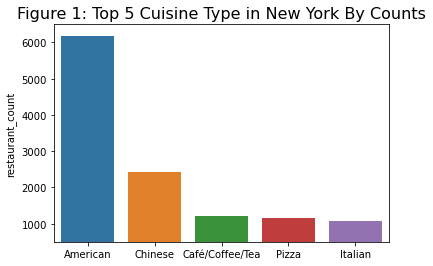

In [4]:
#corresponding visualization for query 1:
rstrt_v1=sns.barplot( x=rstrt_1.cuisine, y=rstrt_1.restaurant_count)
rstrt_v1.set_title("Figure 1: Top 5 Cuisine Type in New York By Counts", fontsize=16)
rstrt_v1.set_ylim(500,6500)
rstrt_v1.set_xlabel("")

#### Analysis for Q1:
Figure 1 shows that Top 5 most popular cuisine types in New York are American, Chinese cuisines, cafe & tea places, Pizza and Italian foods. With more than 6,000 restaurants, American cuisine dominates New York food service market, followed by Chinese cuisine. 

### 3.2 What are the Top 10 highest scored restaurants for American and Chinese cuisine respectively with 5 consecutive A in the most recent grades?
These Top 10 best-scored American and Chinese restaurants can be put in the "Top rated popular cuisines" section of opening page of the app. This tells users what places they can visit if they want to try the featuring cuisines in New York. 

In [5]:
#corresponding query 2:

rstrt_2 =db.restaurant.aggregate([{"$match":{"cuisine":"American","grades.0.grade":"A",
                                             "grades.1.grade":"A","grades.2.grade":"A", 
                                             "grades.3.grade":"A", "grades.4.grade":"A"}},
{"$project":{"name":1,"borough":1,"_id":0, "avg_score":{"$avg":"$grades.score"}}},
{"$sort":{"avg_score":-1}},
{"$limit":10}])


In [6]:
# store the result and save as a dataframe
rstrt_2=list(rstrt_2)
rstrt_2 = pd.DataFrame.from_records(json_normalize(rstrt_2))
rstrt_2

,borough,name,avg_score
0,Queens,Panera Bread,17.833333
1,Manhattan,George'S,16.166667
2,Manhattan,Gotham Cafe (Inside Holiday Inn),15.500000
3,Manhattan,Le Basket,15.142857
4,Manhattan,44 1/2 Cafe,14.833333
5,Manhattan,Gee Whiz,14.428571
6,Bronx,Zerega Avenue Deli,14.428571
7,Queens,Unforgettable Lounge,14.333333
8,Staten Island,Bermay Luncheonette,14.000000
9,Manhattan,Emerald Pub,13.666667


In [7]:
#corresponding query 3:
rstrt_3 = db.restaurant.aggregate([{"$match":{"cuisine":"Chinese","grades.0.grade":"A",
                                              "grades.1.grade":"A","grades.2.grade":"A", 
                                              "grades.3.grade":"A", "grades.4.grade":"A"}},
{"$project":{"name":1,"borough":1,"_id":0, "avg_score":{"$avg":"$grades.score"}}},
{"$sort":{"avg_score":-1}},
{"$limit":10}]);

In [8]:
# store the result and save as a dataframe
rstrt_3=list(rstrt_3)
rstrt_3 = pd.DataFrame.from_records(json_normalize(rstrt_3))
rstrt_3

,borough,name,avg_score
0,Queens,Happy Fortune Restaurant,19.714286
1,Brooklyn,Dragon House,15.833333
2,Manhattan,Xi'An Famous Foods,13.500000
3,Queens,East Dragon,13.333333
4,Queens,Baybridge Szechuan Restaurant,13.166667
5,Bronx,Mei Chung Mei Restaurant,13.000000
6,Manhattan,''U'' Like Chinese Restaurant,12.800000
7,Manhattan,Dim Sum Go Go,12.500000
8,Bronx,Happy Garden Restaurant,12.166667
9,Manhattan,Jing Star Restaurant,12.000000


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Happy Fortune Restaurant'),
  Text(1, 0, 'Dragon House'),
  Text(2, 0, "Xi'An Famous Foods"),
  Text(3, 0, 'East Dragon'),
  Text(4, 0, 'Baybridge Szechuan Restaurant'),
  Text(5, 0, 'Mei Chung  Mei Restaurant'),
  Text(6, 0, "''U'' Like Chinese Restaurant"),
  Text(7, 0, 'Dim Sum Go Go'),
  Text(8, 0, 'Happy Garden Restaurant'),
  Text(9, 0, 'Jing Star Restaurant')])

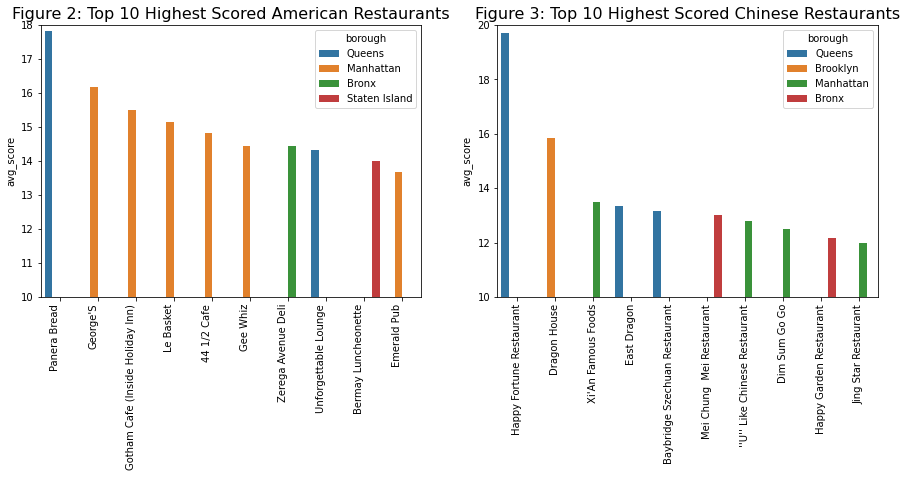

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

####Corresponding visualization for query 2
rstrt_v2=sns.barplot(ax=axes[0], x=rstrt_2.name, 
                     y=rstrt_2.avg_score, hue=rstrt_2.borough)
axes[0].set_title("Figure 2: Top 10 Highest Scored American Restaurants", 
                  fontsize=16)
axes[0].set_ylim(10,18)
axes[0].set_xlabel("")
rstrt_v2.set_xticklabels(rstrt_v2.get_xticklabels(), rotation=90, 
                         horizontalalignment='right')


####Corresponding visualization for query 3
rstrt_v3=sns.barplot(ax=axes[1], x=rstrt_3.name, 
                     y=rstrt_3.avg_score,hue=rstrt_3.borough)
axes[1].set_title("Figure 3: Top 10 Highest Scored Chinese Restaurants",
                  fontsize=16)
axes[1].set_ylim(10,20)
axes[1].set_xlabel("")
plt.xticks(rotation=90)



#### Analysis for Q2
Figure 2 and 3 list Top 10 best-scored American and Chinese restaurants respectively in New York. All the 20 restaurants have been graded "A" by customers in the most recent 5 comments. Figure 2 shows that Manhattan borough is the best choice for people who like American food while both Queens and Manhattan have good Chinese restaurants.  

#### 3.3 How many restaurant choices are there in each borough?
Other than finding popular cuisines, many customers also want to know which boroughs have the most restaurant options so they can have more choices within a specific borough. 

In [11]:
#corresponding query 4:

rstrt_4 = db.restaurant.aggregate([
{"$group": {"_id": {"borough":"$borough"}, 
    "restaurant_count":{"$sum": 1}}},
{"$sort":{"restaurant_count":-1}},
{"$limit":5}
]);

In [12]:
# store the result and save as a dataframe
rstrt_4=list(rstrt_4)
rstrt_4 = pd.DataFrame.from_records(json_normalize(rstrt_4))
rstrt_4.rename(columns = {'_id.borough':'borough'}, inplace = True)
rstrt_4

,restaurant_count,borough
0,10259,Manhattan
1,6086,Brooklyn
2,5656,Queens
3,2338,Bronx
4,969,Staten Island


Text(0.5, 0, '')

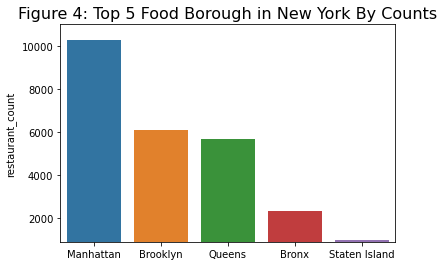

In [13]:
#corresponding visualization for query 4:
rstrt_v4=sns.barplot( x=rstrt_4.borough, y=rstrt_4.restaurant_count)
rstrt_v4.set_title("Figure 4: Top 5 Food Borough in New York By Counts", 
                   fontsize=16)
rstrt_v4.set_ylim(900,11000)
rstrt_v4.set_xlabel("")

#### Analysis for Q3:
Figure 4 shows that Manhattan is where most restaurants are located. Brookly is also a popular venue for food service providers. 

#### 3.4 What are the Top 10 highest scored places in Manhattan and Brooklyn with 5 consecutive A in most recent grades?
As Manhattan and Brooklyn have the widest options, it is useful to put good restaurants in these two boroughs in front page. For consumers who do not know what to eat but want to go for a borough with many restaurant options, they can check Manhattan and Brooklyn.  

In [14]:
#corresponding query 5:

rstrt_5 =db.restaurant.aggregate([{"$match":{"borough":"Manhattan","grades.0.grade":"A",
                                             "grades.1.grade":"A", "grades.2.grade":"A", 
                                             "grades.3.grade":"A", "grades.4.grade":"A"}},
{"$project":{"name":1,"cuisine":1,"_id":0, "avg_score":{"$avg":"$grades.score"}}},
{"$sort":{"avg_score":-1}},
{"$limit":10}])

In [15]:
# store the result and save as a dataframe
rstrt_5=list(rstrt_5)
rstrt_5 = pd.DataFrame.from_records(json_normalize(rstrt_5))
rstrt_5

,cuisine,name,avg_score
0,Asian,Alpha Fusion,16.333333
1,American,George'S,16.166667
2,American,Gotham Cafe (Inside Holiday Inn),15.500000
3,"Latin (Cuban, Dominican, Puerto Rican, South &...",El Nuevo Amanecer Restaurant,15.333333
4,Thai,Enthaice,15.166667
5,American,Le Basket,15.142857
6,American,44 1/2 Cafe,14.833333
7,German,Blaue Gans,14.714286
8,Jewish/Kosher,Bagel Boss,14.500000
9,American,Gee Whiz,14.428571


In [16]:
#corresponding query 6:
rstrt_6=db.restaurant.aggregate([{"$match":{"borough":"Brooklyn","grades.0.grade":"A",
                                            "grades.1.grade":"A", "grades.2.grade":"A", 
                                            "grades.3.grade":"A", "grades.4.grade":"A"}},
{"$project":{"name":1,"cuisine":1,"_id":0, "avg_score":{"$avg":"$grades.score"}}},
{"$sort":{"avg_score":-1}},
{"$limit":10}])

In [17]:
# store the result and save as a dataframe
rstrt_6=list(rstrt_6)
rstrt_6 = pd.DataFrame.from_records(json_normalize(rstrt_6))
rstrt_6

,cuisine,name,avg_score
0,Brazilian,Miss Favela,17.000000
1,Chinese,Dragon House,15.833333
2,Jewish/Kosher,Amnon Kosher Pizza,14.857143
3,Pizza,Antonio'S Pizza,14.666667
4,Sandwiches,Subway,14.166667
5,Tex-Mex,Taco Chulo,13.833333
6,Pizza/Italian,Brooklyn Pizza,13.714286
7,Mexican,Antojitos Mexicanos,13.285714
8,"Latin (Cuban, Dominican, Puerto Rican, South &...",Deli & Grill,13.000000
9,Delicatessen,One Deli Restaurant,13.000000


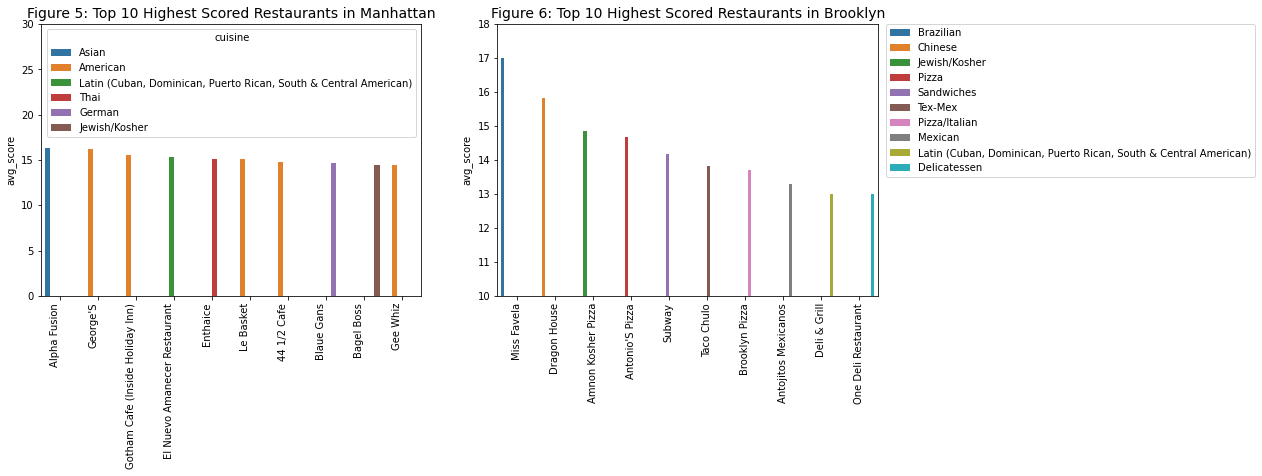

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

####Corresponding visualization for query 5
rstrt_v5=sns.barplot(ax=axes[0], x=rstrt_5.name, 
                     y=rstrt_5.avg_score, hue=rstrt_5.cuisine)
axes[0].set_title("Figure 5: Top 10 Highest Scored Restaurants in Manhattan", 
                  fontsize=14)
axes[0].set_ylim(0,30)
axes[0].set_xlabel("")
rstrt_v5.set_xticklabels(rstrt_v5.get_xticklabels(), 
                         rotation=90, horizontalalignment='right')


####Corresponding visualization for query 6
rstrt_v6=sns.barplot(ax=axes[1], x=rstrt_6.name, 
                     y=rstrt_6.avg_score,hue=rstrt_6.cuisine)
axes[1].set_title("Figure 6: Top 10 Highest Scored Restaurants in Brooklyn",
                  fontsize=14)
axes[1].set_ylim(10,18)
axes[1].set_xlabel("")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)



#### Analysis for Q4
Figure 5 and 6 list Top 10 best restaurants with 5 consecutive grade "A" recently in Manhattan and Brooklyn respectively. Six cuisine types are available for consumers if they want to try Top 10 places in Manhattan. If people want to try Top 10 in Brooklyn, they have 10 types available!  

### 4. Decision & Recommendations
1. In the front page, inform consumers the Top 5 most popular cuisine types in New York. 
2. Put the information of the Top 10 best-scored American and Chinese restaurants and ensure consumers can see it when they open the app. 
3. Also list the Top 10 best restuarants in Manhattan and Brooklyn for customers. 

In [1]:
### import packages and connect with db
from pymongo import MongoClient
from pandas import json_normalize
import json
from pprint import pprint as pp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client = MongoClient('mongodb://34.162.70.169:27017/mongodbrstrt')